## Problema

Objetivo: detectar transações fraudulentas.

Tipos de erro:
- False Negative → fraude passa (alto custo 💸)
- False Positive → bloqueio indevido (impacto cliente)

Métrica ideal: Recall ou ROC-AUC

In [49]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Carregamento dos dados

In [97]:
df = pd.read_csv('../data/raw/fraud_dataset_20260421_232806.csv')

# Analise inicial do dataframe

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valor             200000 non-null  float64
 1   hora              200000 non-null  int64  
 2   dispositivo_novo  200000 non-null  bool   
 3   tentativas_24h    200000 non-null  int64  
 4   distancia_km      200000 non-null  float64
 5   fraude            200000 non-null  int64  
dtypes: bool(1), float64(2), int64(3)
memory usage: 7.8 MB


In [52]:
df.describe()

,valor,hora,tentativas_24h,distancia_km,fraude
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2507.824323,11.479945,2.494640,996.784190,0.187590
std,1440.187933,6.919832,1.705452,578.038618,0.390385
min,10.030000,0.000000,0.000000,0.010000,0.000000
25%,1262.260000,5.000000,1.000000,497.897500,0.000000
50%,2512.195000,11.000000,2.000000,994.575000,0.000000
75%,3757.280000,17.000000,4.000000,1497.070000,0.000000
max,4999.980000,23.000000,5.000000,2000.000000,1.000000


# Distribuição da variável alvo 

Text(0.5, 1.0, 'Distribuição das Classes (162482: Legitima, 37518: Fraude)')

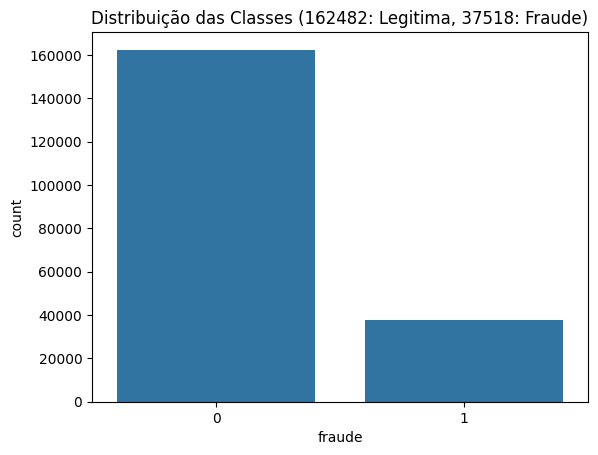

In [53]:
df['fraude'].value_counts()
df_2 = df['fraude'].value_counts()
sns.countplot(x='fraude', data=df)
plt.title(f'Distribuição das Classes ({df_2[0]}: Legitima, {df_2[1]}: Fraude)')

Nota: Dataset muito desbalanceado:

# Correlação entre as variaveis 

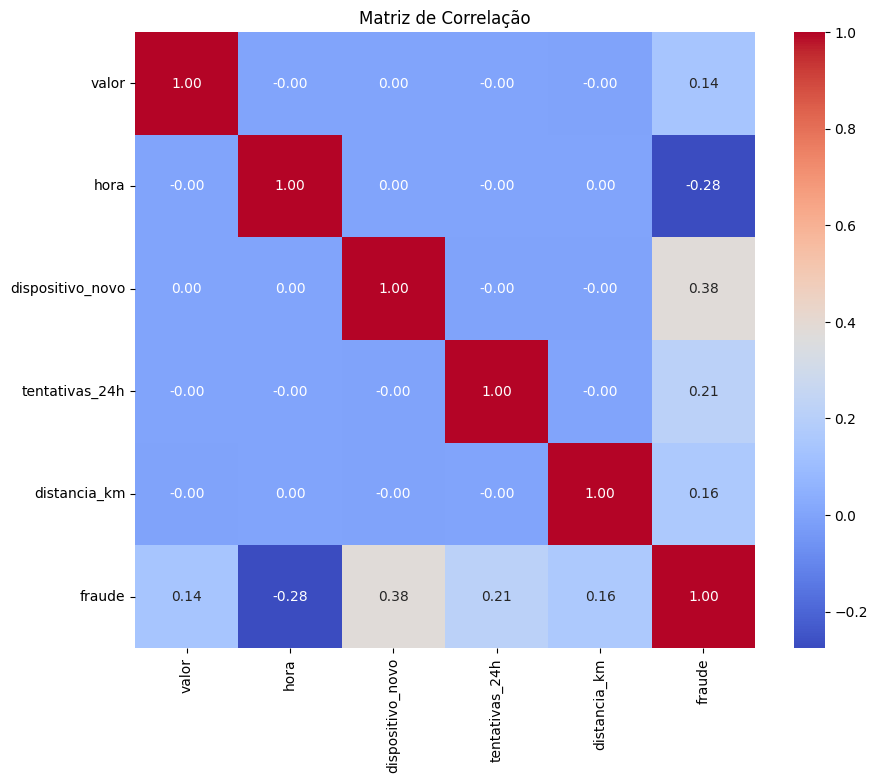

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

In [55]:
df.corr(numeric_only=True)["fraude"].sort_values(ascending=False)

fraude              1.000000
dispositivo_novo    0.379410
tentativas_24h      0.214013
distancia_km        0.158454
valor               0.141411
hora               -0.275297
Name: fraude, dtype: float64

# Distribuição de Fraude por Hora do Dia

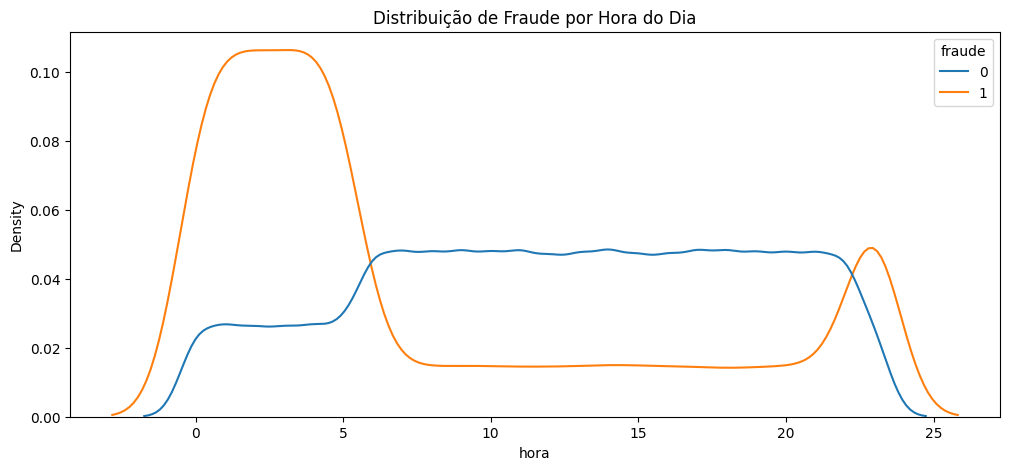

In [56]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x='hora', hue='fraude', common_norm=False)
plt.title("Distribuição de Fraude por Hora do Dia")
plt.show()

# Distribuição de Valor por Status de Fraude

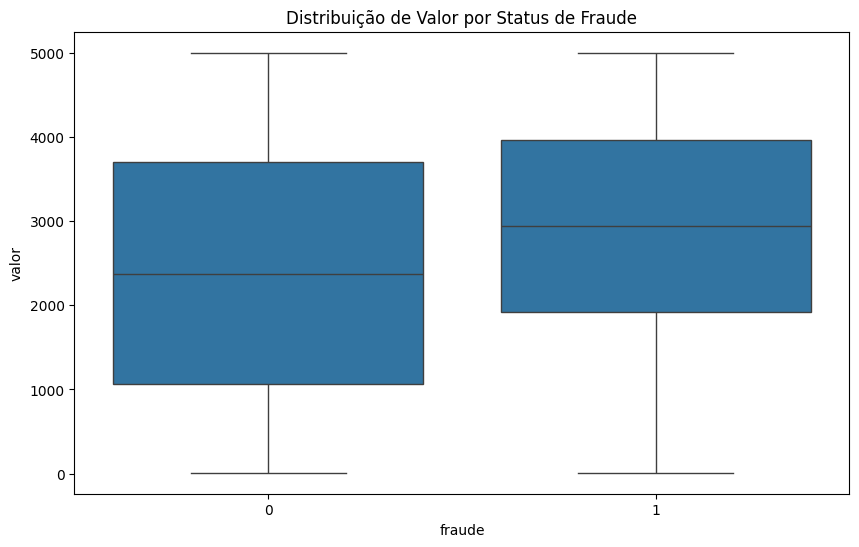

In [57]:
# Comparando Valor e Fraude com Boxplot para ver Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='fraude', y='valor', data=df)
plt.title('Distribuição de Valor por Status de Fraude')
plt.show()

<Axes: xlabel='fraude', ylabel='valor'>

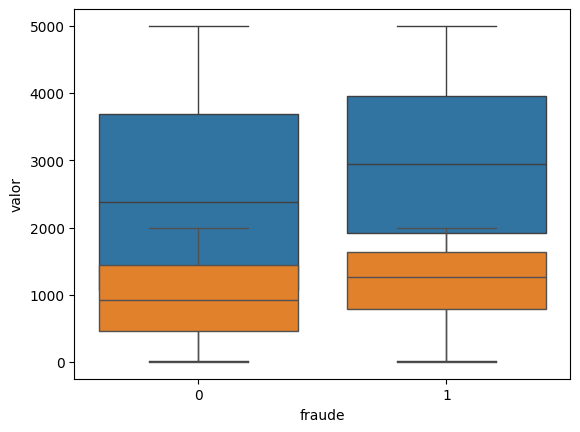

In [58]:
sns.boxplot(x='fraude', y='valor', data=df)
sns.boxplot(x='fraude', y='distancia_km', data=df)

<Axes: xlabel='hora', ylabel='Count'>

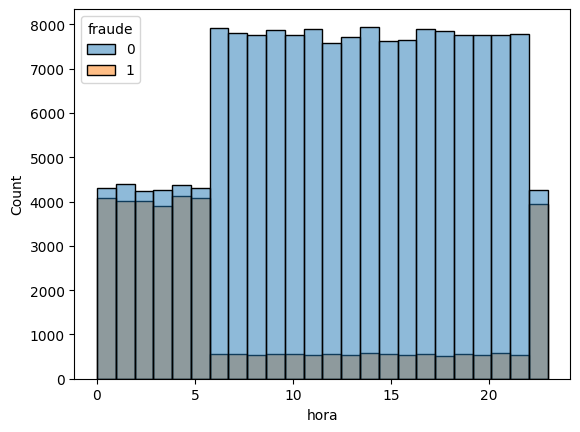

In [59]:
sns.histplot(data=df, x='hora', hue='fraude', bins=24)

# Taxa de fraude por dispositivos

In [60]:
pd.crosstab(df['dispositivo_novo'], df['fraude'], normalize='index')

fraude,0,1
dispositivo_novo,,
False,0.960616,0.039384
True,0.664385,0.335615


# Media de valores por classe

In [61]:
df.groupby("fraude")["valor"].mean()

fraude
0    2409.961104
1    2931.647863
Name: valor, dtype: float64

# Tentativas

<Axes: xlabel='fraude', ylabel='tentativas_24h'>

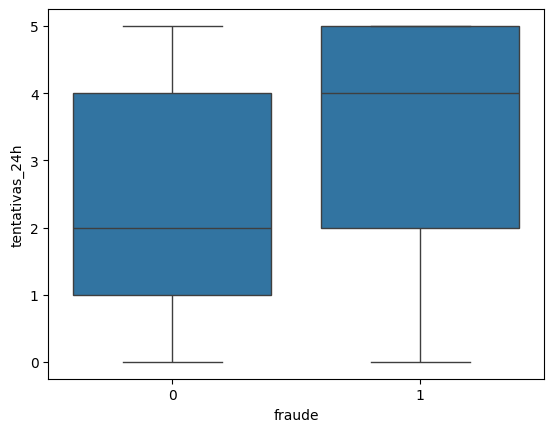

In [62]:
sns.boxplot(x='fraude', y='tentativas_24h', data=df)

# Feature Engineering

Remoção de Viés: tentativas_24h
A coluna tentativas_24h foi removida para garantir a integridade do modelo:

A variável apresentava uma importância desproporcional (dominando o modelo), indicando que continha informação "do futuro" ou retroalimentada pelo sistema após a transação ser suspeita.

Generalização: Sem esse "atalho", o modelo é forçado a aprender padrões comportamentais reais (valor, hora, distância)

Fim do Overfitting: A remoção elimina o score irreal de 1.0, resultando em um modelo que reflete a performance real em produção.

In [ ]:
df = df.drop(columns=['tentativas_24h'])

In [ ]:
# Transformação Cíclica da Hora (Seno e Cosseno)
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# Transformação Logarítmica (Suaviza valores altos de Valor e Distância)
df['valor_log'] = np.log1p(df['valor'])
df['distancia_log'] = np.log1p(df['distancia_km'])

# Converte Booleano para 0 e 1
df['dispositivo_novo'] = df['dispositivo_novo'].astype(int)

In [116]:
df = df.drop(columns=['valor', 'distancia_km', 'hora'])

Hipóteses:
- transações noturnas → maior risco
- distância alta + muitas tentativas → comportamento suspeito

# BASELINE MODEL

# 1. Separação correta dos dados

In [117]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['fraude'])
y = df['fraude']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2. Pipeline Inicial

In [118]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1. Definindo o Pipeline da Regressão Logística (o que você já tinha)
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

# 2. Definindo o Pipeline da Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()), # Opcional para RF, mas mantido por padrão
    ('model', RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42))
])

# 3. Treinar baseline

In [119]:
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2


# 4. Métricas

In [120]:
# 4. Calculando Probabilidades e AUC para Regressão Logística
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)

# 5. Calculando Probabilidades e AUC para Random Forest
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)

# Exibindo os resultados
print(f"ROC AUC - Regressão Logística: {auc_lr:.4f}")
print(f"ROC AUC - Random Forest:      {auc_rf:.4f}")

ROC AUC - Regressão Logística: 0.9199
ROC AUC - Random Forest:      0.9671


# 7. Feature importance

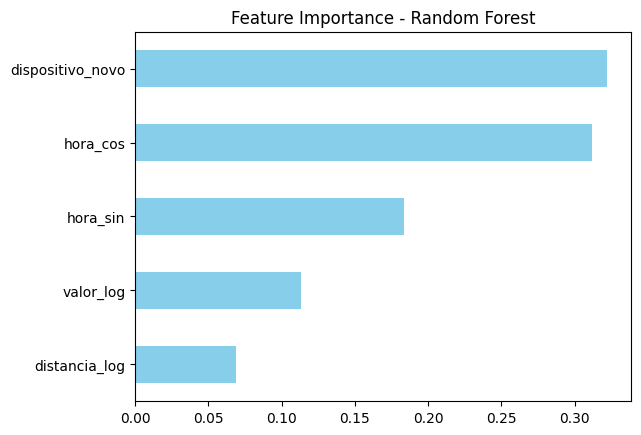

In [121]:
# Feature Importance na Random Forest

import matplotlib.pyplot as plt

# Extrair as importâncias do modelo dentro do pipeline
importances = pipeline_rf.named_steps['model'].feature_importances_
feature_names = X.columns

# Criar um Series para facilitar a plotagem
rf_importance = pd.Series(importances, index=feature_names).sort_values(ascending=True)

rf_importance.plot(kind='barh', color='skyblue')
plt.title('Feature Importance - Random Forest')
plt.show()

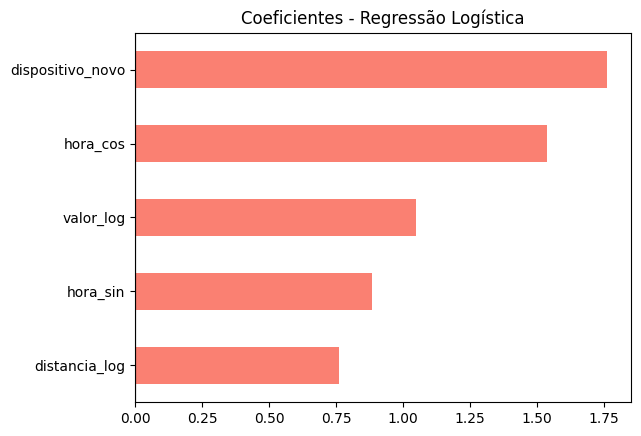

In [122]:
# Coeficientes na Regressão Logística

# Extrair coeficientes
coeffs = pipeline_lr.named_steps['model'].coef_[0]

# Criar o gráfico
lr_importance = pd.Series(coeffs, index=feature_names).sort_values(ascending=True)

lr_importance.plot(kind='barh', color='salmon')
plt.title('Coeficientes - Regressão Logística')
plt.axvline(0, color='black', lw=0.8) # Linha no zero para separar positivo/negativo
plt.show()

In [ ]:
import pandas as pd

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')

# 8. MLflow